# Milestone 0 — Data Download and Inventory

Verify what is on disk before any analysis. Deliverable: coverage matrix (subjects × tasks → run counts).

**Dataset:** OpenNeuro ds004194 v3.0.0  
**Target subjects:** p02, p06, p07, p10 (validation / Groen 2022 spatialpattern task) + p13, p14 (primary / Brands 2024 natural-image task)

In [1]:
import os
import json
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_ROOT = '/Users/winstonluk/Documents/NEURON/FinalProject/data/ds004194'
DERIV_ROOT = os.path.join(DATA_ROOT, 'derivatives')

TARGET_SUBS   = ['p02', 'p06', 'p07', 'p10', 'p13', 'p14']
VALID_SUBS    = ['p02', 'p06', 'p07', 'p10']   # Groen 2022 validation cohort
PRIMARY_SUBS  = ['p13', 'p14']                  # Brands 2024 primary cohort

print(f'DATA_ROOT exists: {os.path.isdir(DATA_ROOT)}')

DATA_ROOT exists: True


## 1. Top-level directory tree

In [2]:
# Subject directories
subs = sorted([d for d in os.listdir(DATA_ROOT) if d.startswith('sub-p')])
print(f'Subject directories ({len(subs)}): {subs}')

# Derivatives folders
derivs = sorted(os.listdir(DERIV_ROOT))
print(f'\nDerivatives folders ({len(derivs)}):')
for d in derivs:
    print(f'  {d}')

Subject directories (14): ['sub-p01', 'sub-p02', 'sub-p03', 'sub-p04', 'sub-p05', 'sub-p06', 'sub-p07', 'sub-p08', 'sub-p09', 'sub-p10', 'sub-p11', 'sub-p12', 'sub-p13', 'sub-p14']

Derivatives folders (8):
  Brandsetal2024TemporalAdaptationECoG
  ECoGBroadband
  ECoGCAR
  ECoGPreprocessed
  Groenetal2022TemporalDynamicsECoG
  Yuasa2023AlphaPRF
  freesurfer
  preprocessing_logs


## 2. Participants metadata

In [3]:
participants = pd.read_csv(os.path.join(DATA_ROOT, 'participants.tsv'), sep='\t')
participants['participant_id'] = participants['participant_id'].str.replace('sub-', '')
participants = participants.set_index('participant_id')
print(participants[['age', 'sex', 'site', 'high_density_grid']].to_string())

                age     sex  site high_density_grid
participant_id                                     
p01              30  Female  UMCU                no
p02              18  Female  UMCU                no
p03              27    Male   NYU                no
p04              28    Male   NYU                no
p05              31  Female   NYU                no
p06              19  Female   NYU                no
p07              41  Female   NYU                no
p08              47    Male   NYU                no
p09              25    Male   NYU                no
p10              23    Male   NYU               yes
p11              19  Female   NYU               yes
p12              42    Male   NYU                no
p13              22  Female   NYU                no
p14              32  Female   NYU                no


## 3. BIDS task labels — confirmed actual labels on disk

In [4]:
# Collect all task labels actually present in the dataset (via events.tsv filenames)
all_task_labels = set()
for sub in subs:
    sub_dir = os.path.join(DATA_ROOT, sub)
    for ses in os.listdir(sub_dir):
        ieeg_dir = os.path.join(sub_dir, ses, 'ieeg')
        if not os.path.isdir(ieeg_dir):
            continue
        for f in os.listdir(ieeg_dir):
            if f.endswith('_events.tsv'):
                parts = f.split('_')
                for p in parts:
                    if p.startswith('task-'):
                        all_task_labels.add(p.replace('task-', ''))

print('All task labels found on disk:')
for t in sorted(all_task_labels):
    print(f'  task-{t}')

print()
print('CLAUDE.md scaffold guessed: task-sixcatlocdiffisidur')
print('Actual labels for Brands task: task-sixcatlocdiffisi, task-sixcatloctemporal')

All task labels found on disk:
  task-prf
  task-sixcatlocdiffisi
  task-sixcatlocisidiff
  task-sixcatloctemporal
  task-soc
  task-spatialpattern
  task-temporalpattern

CLAUDE.md scaffold guessed: task-sixcatlocdiffisidur
Actual labels for Brands task: task-sixcatlocdiffisi, task-sixcatloctemporal


## 4. Coverage matrix — subjects × tasks → run counts

In [5]:
def count_runs(sub, task):
    """Count events.tsv files matching sub + task across all sessions."""
    sub_dir = os.path.join(DATA_ROOT, f'sub-{sub}')
    count = 0
    for ses in os.listdir(sub_dir):
        ieeg_dir = os.path.join(sub_dir, ses, 'ieeg')
        if not os.path.isdir(ieeg_dir):
            continue
        for f in os.listdir(ieeg_dir):
            if f'task-{task}_' in f and f.endswith('_events.tsv'):
                count += 1
    return count


TASKS = ['prf', 'spatialpattern', 'temporalpattern', 'sixcatlocdiffisi', 'sixcatloctemporal']

coverage = {}
for sub in TARGET_SUBS:
    coverage[sub] = {task: count_runs(sub, task) for task in TASKS}

coverage_df = pd.DataFrame(coverage, index=TASKS).T
coverage_df.index.name = 'subject'

print('=== Coverage matrix: subjects × tasks → run counts ===')
print(coverage_df.to_string())

=== Coverage matrix: subjects × tasks → run counts ===
         prf  spatialpattern  temporalpattern  sixcatlocdiffisi  sixcatloctemporal
subject                                                                           
p02        2               2                2                 0                  0
p06        2               4                4                 0                  0
p07        4               8                8                 0                  0
p10        6              12               12                 0                  0
p13        2               0                0                 4                  4
p14        2               0                0                 3                  2


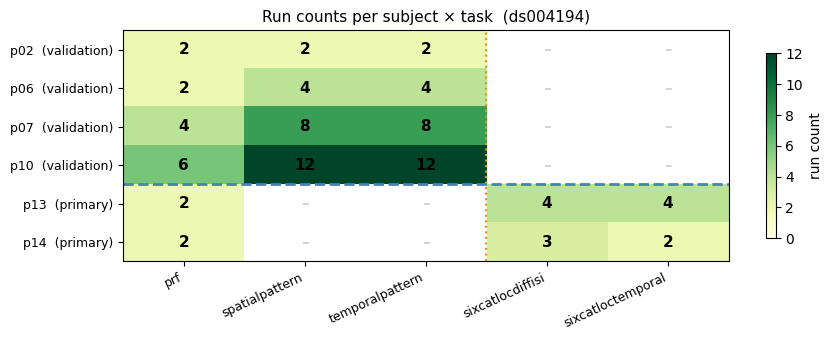

Saved: /Users/winstonluk/Documents/NEURON/FinalProject/results/milestone_00_coverage_matrix.png


In [6]:
# Visual coverage heatmap
fig, ax = plt.subplots(figsize=(9, 3.5))

data = coverage_df.values.astype(float)
data_masked = np.where(data == 0, np.nan, data)

im = ax.imshow(data_masked, aspect='auto', cmap='YlGn', vmin=0)

# Annotate cells
for i, sub in enumerate(coverage_df.index):
    role = '(primary)' if sub in PRIMARY_SUBS else '(validation)'
    for j, task in enumerate(coverage_df.columns):
        val = int(coverage_df.loc[sub, task])
        color = 'black' if val > 0 else 'lightgray'
        ax.text(j, i, str(val) if val > 0 else '–',
                ha='center', va='center', fontsize=11, color=color, fontweight='bold')

ax.set_xticks(range(len(TASKS)))
ax.set_xticklabels(TASKS, rotation=25, ha='right', fontsize=9)
ax.set_yticks(range(len(TARGET_SUBS)))
ax.set_yticklabels(
    [f'{s}  {"(primary)" if s in PRIMARY_SUBS else "(validation)"}' for s in TARGET_SUBS],
    fontsize=9
)
ax.set_title('Run counts per subject × task  (ds004194)', fontsize=11)

# Divider between validation and primary cohorts
ax.axhline(3.5, color='steelblue', lw=2, linestyle='--')
ax.axvline(2.5, color='darkorange', lw=1.5, linestyle=':')

plt.colorbar(im, ax=ax, label='run count', shrink=0.8)
plt.tight_layout()

out_path = '/Users/winstonluk/Documents/NEURON/FinalProject/results/milestone_00_coverage_matrix.png'
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## 5. Broadband derivative inventory per target subject

In [7]:
def count_broadband_runs(sub, task):
    """Count broadband ieeg.json sidecars (present = derivative exists for that run)."""
    total = 0
    bb_root = os.path.join(DERIV_ROOT, 'ECoGBroadband', f'sub-{sub}')
    if not os.path.isdir(bb_root):
        return 0
    for ses in os.listdir(bb_root):
        ieeg_dir = os.path.join(bb_root, ses, 'ieeg')
        if not os.path.isdir(ieeg_dir):
            continue
        for f in os.listdir(ieeg_dir):
            if f'task-{task}_' in f and 'broadband_ieeg.json' in f:
                total += 1
    return total


def count_broadband_eeg(sub, task):
    """Count broadband .eeg files (data actually downloaded by datalad)."""
    total = 0
    bb_root = os.path.join(DERIV_ROOT, 'ECoGBroadband', f'sub-{sub}')
    if not os.path.isdir(bb_root):
        return 0
    for ses in os.listdir(bb_root):
        ieeg_dir = os.path.join(bb_root, ses, 'ieeg')
        if not os.path.isdir(ieeg_dir):
            continue
        for f in os.listdir(ieeg_dir):
            if f'task-{task}_' in f and f.endswith('broadband_ieeg.eeg'):
                fp = os.path.join(ieeg_dir, f)
                if not os.path.islink(fp) or os.path.exists(fp):
                    total += 1
    return total


rows = []
for sub in TARGET_SUBS:
    role = 'primary' if sub in PRIMARY_SUBS else 'validation'
    site = participants.loc[sub, 'site']
    for task in TASKS:
        n_runs = count_runs(sub, task)
        n_bb_sidecars = count_broadband_runs(sub, task)
        n_bb_eeg = count_broadband_eeg(sub, task)
        if n_runs > 0 or n_bb_sidecars > 0:
            rows.append(dict(subject=sub, role=role, site=site, task=task,
                             raw_runs=n_runs, bb_sidecars=n_bb_sidecars,
                             bb_eeg_downloaded=n_bb_eeg))

inv_df = pd.DataFrame(rows)
print(inv_df.to_string(index=False))

subject       role site              task  raw_runs  bb_sidecars  bb_eeg_downloaded
    p02 validation UMCU               prf         2            2                  0
    p02 validation UMCU    spatialpattern         2            2                  0
    p02 validation UMCU   temporalpattern         2            2                  0
    p06 validation  NYU               prf         2            2                  0
    p06 validation  NYU    spatialpattern         4            4                  0
    p06 validation  NYU   temporalpattern         4            4                  0
    p07 validation  NYU               prf         4            4                  0
    p07 validation  NYU    spatialpattern         8            8                  0
    p07 validation  NYU   temporalpattern         8            8                  0
    p10 validation  NYU               prf         6            6                  0
    p10 validation  NYU    spatialpattern        12           12            

## 6. Electrode counts per target subject

In [8]:
import csv

SESSION_MAP = {
    'p02': 'ses-umcuiemu01',
    'p06': 'ses-nyuecog01',
    'p07': 'ses-nyuecog01',
    'p10': 'ses-nyuecog01',
    'p13': 'ses-nyuecog01',
    'p14': 'ses-nyuecog01',
}

elec_rows = []
for sub in TARGET_SUBS:
    ses = SESSION_MAP[sub]
    elec_f = os.path.join(DATA_ROOT, f'sub-{sub}', ses, 'ieeg',
                          f'sub-{sub}_{ses}_acq-clinical_electrodes.tsv')
    if not os.path.exists(elec_f):
        print(f'  WARNING: no electrodes.tsv for {sub}')
        continue
    df = pd.read_csv(elec_f, sep='\t')
    n_total = len(df)
    site = participants.loc[sub, 'site']
    hd = participants.loc[sub, 'high_density_grid']
    elec_rows.append(dict(subject=sub, site=site, hd_grid=hd, n_electrodes=n_total))

elec_df = pd.DataFrame(elec_rows)
print(elec_df.to_string(index=False))

subject site hd_grid  n_electrodes
    p02 UMCU      no            56
    p06  NYU      no           142
    p07  NYU      no           122
    p10  NYU     yes           252
    p13  NYU      no           116
    p14  NYU      no            94


## 7. Trial structure — categories and stimulus counts

In [9]:
# Primary cohort: six-category natural-image task
print('=== Primary cohort (Brands task) ===' )
for sub in PRIMARY_SUBS:
    ses = SESSION_MAP[sub]
    all_trials = []
    for task in ['sixcatlocdiffisi', 'sixcatloctemporal']:
        bb_dir = os.path.join(DERIV_ROOT, 'ECoGBroadband', f'sub-{sub}', ses, 'ieeg')
        if not os.path.isdir(bb_dir):
            continue
        for f in sorted(os.listdir(bb_dir)):
            if f'task-{task}_' in f and 'events.tsv' in f:
                df = pd.read_csv(os.path.join(bb_dir, f), sep='\t')
                df['sub_task'] = f'{sub}/{task}'
                all_trials.append(df)
    if all_trials:
        combined = pd.concat(all_trials, ignore_index=True)
        cats = combined['trial_name'].str.extract(r'^([A-Z]+)-')[0]
        print(f'  {sub}: {len(combined)} total trials, categories: {dict(cats.value_counts().sort_index())}')

print()
print('=== Validation cohort (spatialpattern task) ===')
for sub in VALID_SUBS:
    ses = SESSION_MAP[sub]
    all_trials = []
    bb_dir = os.path.join(DERIV_ROOT, 'ECoGBroadband', f'sub-{sub}', ses, 'ieeg')
    if not os.path.isdir(bb_dir):
        continue
    for f in sorted(os.listdir(bb_dir)):
        if 'task-spatialpattern_' in f and 'events.tsv' in f:
            df = pd.read_csv(os.path.join(bb_dir, f), sep='\t')
            all_trials.append(df)
    if all_trials:
        combined = pd.concat(all_trials, ignore_index=True)
        conds = combined['trial_name'].value_counts().sort_index()
        print(f'  {sub}: {len(combined)} total trials, unique conditions: {combined["trial_name"].nunique()}')
        print(f'    Conditions: {list(conds.index)}')

=== Primary cohort (Brands task) ===
  p13: 1152 total trials, categories: {'BODIES': np.int64(192), 'BUILDINGS': np.int64(192), 'FACES': np.int64(192), 'OBJECTS': np.int64(192), 'SCENES': np.int64(192), 'SCRAMBLED': np.int64(192)}
  p14: 720 total trials, categories: {'BODIES': np.int64(120), 'BUILDINGS': np.int64(120), 'FACES': np.int64(120), 'OBJECTS': np.int64(120), 'SCENES': np.int64(120), 'SCRAMBLED': np.int64(120)}

=== Validation cohort (spatialpattern task) ===
  p02: 72 total trials, unique conditions: 12
    Conditions: ['CIRCULAR', 'CRF-1', 'CRF-2', 'CRF-3', 'CRF-4', 'CRF-5', 'GRATING', 'PLAID', 'SPARSITY-1', 'SPARSITY-2', 'SPARSITY-3', 'SPARSITY-4']
  p06: 144 total trials, unique conditions: 12
    Conditions: ['CIRCULAR', 'CRF-1', 'CRF-2', 'CRF-3', 'CRF-4', 'CRF-5', 'GRATING', 'PLAID', 'SPARSITY-1', 'SPARSITY-2', 'SPARSITY-3', 'SPARSITY-4']
  p07: 144 total trials, unique conditions: 12
    Conditions: ['CIRCULAR', 'CRF-1', 'CRF-2', 'CRF-3', 'CRF-4', 'CRF-5', 'GRATING', 

## 8. Datalad download status — what needs `datalad get`

In [10]:
def audit_directory(path):
    """Return (accessible_count, missing_count) for a directory tree."""
    acc, miss = 0, 0
    for root, dirs, files in os.walk(path):
        dirs[:] = [d for d in dirs if d != '.git']
        for f in files:
            fp = os.path.join(root, f)
            if os.path.islink(fp) and not os.path.exists(fp):
                miss += 1
            else:
                acc += 1
    return acc, miss


DERIV_DIRS = [
    'ECoGBroadband',
    'ECoGCAR',
    'ECoGPreprocessed',
    'Groenetal2022TemporalDynamicsECoG',
    'Brandsetal2024TemporalAdaptationECoG',
    'freesurfer',
    'Yuasa2023AlphaPRF',
]

print(f'{"Derivative":<45} {"Accessible":>12} {"Missing":>10} {"% downloaded":>14}')
print('-' * 84)
for d in DERIV_DIRS:
    acc, miss = audit_directory(os.path.join(DERIV_ROOT, d))
    total = acc + miss
    pct = 100 * acc / total if total > 0 else 0
    flag = ' *** NEEDS GET' if miss > 0 else ''
    print(f'{d:<45} {acc:>12} {miss:>10} {pct:>13.0f}%{flag}')

Derivative                                      Accessible    Missing   % downloaded
------------------------------------------------------------------------------------
ECoGBroadband                                          627        838            43% *** NEEDS GET
ECoGCAR                                                627       1335            32% *** NEEDS GET
ECoGPreprocessed                                         0          4             0% *** NEEDS GET
Groenetal2022TemporalDynamicsECoG                        0         24             0% *** NEEDS GET
Brandsetal2024TemporalAdaptationECoG                     0       4093             0% *** NEEDS GET


freesurfer                                               4       5175             0% *** NEEDS GET
Yuasa2023AlphaPRF                                        0        194             0% *** NEEDS GET


In [11]:
# Key files needed for each milestone — check specific paths
print('=== Key file availability check ===')
print()

checks = [
    # Milestone 1 (atlas labels)
    ('M1 - freesurfer wang15 label (p14 LH)',
     os.path.join(DERIV_ROOT, 'freesurfer', 'sub-p14', 'surf', 'lh.wang15_mplbl.mgz')),
    ('M1 - freesurfer benson14 varea (p14 LH)',
     os.path.join(DERIV_ROOT, 'freesurfer', 'sub-p14', 'surf', 'lh.benson14_varea.mgz')),
    # Milestone 2 (signal exploration)
    ('M2 - broadband EEG timeseries (p14 sixcatlocdiffisi run-01)',
     os.path.join(DERIV_ROOT, 'ECoGBroadband', 'sub-p14', 'ses-nyuecog01', 'ieeg',
                  'sub-p14_ses-nyuecog01_task-sixcatlocdiffisi_run-01_desc-broadband_ieeg.eeg')),
    # Milestone 3 (Groen validation)
    ('M3 - Groen p06 tdedata.mat',
     os.path.join(DERIV_ROOT, 'Groenetal2022TemporalDynamicsECoG', 'data', 'sub-p06_tdedata.mat')),
    # Milestone 4 (stimulus images — separate GitHub repo, not in ds004194)
    ('M4 - stimuli mat file (p14 run-01)',
     os.path.join(DATA_ROOT, 'stimuli',
                  'sub-p14_ses-nyuecog01_task-sixcatlocdiffisi_acq-clinical_run-01.mat')),
    # Brands pre-computed epochs
    ('Brands pre-computed epochs (p14 ch1)',
     os.path.join(DERIV_ROOT, 'Brandsetal2024TemporalAdaptationECoG', 'data_subjects',
                  'sub-p14', 'epochs_b', 'epochs_b_channel1.txt')),
]

for label, path in checks:
    if not os.path.exists(path) and not os.path.islink(path):
        status = 'NOT PRESENT (path missing)'
    elif os.path.islink(path) and not os.path.exists(path):
        status = 'DATALAD SYMLINK — needs `datalad get`'
    else:
        size = os.path.getsize(path)
        status = f'OK ({size/1e6:.1f} MB)'
    print(f'  [{"OK" if status.startswith("OK") else "MISSING"}] {label}')
    print(f'         -> {status}')

=== Key file availability check ===

  [MISSING] M1 - freesurfer wang15 label (p14 LH)
         -> DATALAD SYMLINK — needs `datalad get`
  [MISSING] M1 - freesurfer benson14 varea (p14 LH)
         -> DATALAD SYMLINK — needs `datalad get`
  [MISSING] M2 - broadband EEG timeseries (p14 sixcatlocdiffisi run-01)
         -> DATALAD SYMLINK — needs `datalad get`
  [MISSING] M3 - Groen p06 tdedata.mat
         -> DATALAD SYMLINK — needs `datalad get`
  [MISSING] M4 - stimuli mat file (p14 run-01)
         -> DATALAD SYMLINK — needs `datalad get`
  [MISSING] Brands pre-computed epochs (p14 ch1)
         -> DATALAD SYMLINK — needs `datalad get`


## 9. Summary and next steps

In [12]:
print('=' * 70)
print('MILESTONE 0 SUMMARY')
print('=' * 70)
print()
print('Dataset: ds004194 (Groen / Brands / Yuasa ECoG dataset)')
print(f'Subjects on disk: p01–p14 (all 14)')
print()
print('Task labels confirmed:')
print('  Validation (Groen 2022)  : task-spatialpattern, task-temporalpattern')
print('  Primary   (Brands 2024) : task-sixcatlocdiffisi, task-sixcatloctemporal')
print('  pRF mapping              : task-prf')
print()
print('Key findings:')
print('  • All BIDS events.tsv and channel/electrode metadata files are accessible.')
print('  • Raw ieeg and broadband EEG timeseries (.eeg) are datalad symlinks')
print('    not yet retrieved — need `datalad get` for those.')
print('  • Freesurfer surface atlases (wang15, benson14 .mgz) are also undownloaded.')
print('  • ECoGPreprocessed .mat files and Brands pre-computed epoch .txt files')
print('    are undownloaded.')
print()
print('Required datalad get commands for Milestone 1 (atlas labels):')
print('  cd data/ds004194')
print('  datalad get derivatives/freesurfer/sub-p{02,06,07,10,13,14}/')
print()
print('Required datalad get commands for Milestone 2 (signal exploration):')
print('  datalad get derivatives/ECoGBroadband/sub-p{13,14}/')
print()
print('Required datalad get commands for Milestone 3 (Groen validation):')
print('  datalad get derivatives/Groenetal2022TemporalDynamicsECoG/')
print('  datalad get derivatives/ECoGBroadband/sub-p{02,06,07,10}/')
print()
print('EXIT CRITERION: filesystem layout known. No surprises. ✓')

MILESTONE 0 SUMMARY

Dataset: ds004194 (Groen / Brands / Yuasa ECoG dataset)
Subjects on disk: p01–p14 (all 14)

Task labels confirmed:
  Validation (Groen 2022)  : task-spatialpattern, task-temporalpattern
  Primary   (Brands 2024) : task-sixcatlocdiffisi, task-sixcatloctemporal
  pRF mapping              : task-prf

Key findings:
  • All BIDS events.tsv and channel/electrode metadata files are accessible.
  • Raw ieeg and broadband EEG timeseries (.eeg) are datalad symlinks
    not yet retrieved — need `datalad get` for those.
  • Freesurfer surface atlases (wang15, benson14 .mgz) are also undownloaded.
  • ECoGPreprocessed .mat files and Brands pre-computed epoch .txt files
    are undownloaded.

Required datalad get commands for Milestone 1 (atlas labels):
  cd data/ds004194
  datalad get derivatives/freesurfer/sub-p{02,06,07,10,13,14}/

Required datalad get commands for Milestone 2 (signal exploration):
  datalad get derivatives/ECoGBroadband/sub-p{13,14}/

Required datalad get co